# Activation → PCA

Open the parquet, run the PCA, show the loadings. No project imports — pandas,
numpy, matplotlib.

Edit `SELECT`. `"*"` means every subject in that cohort; drop a cohort to
exclude it. One atlas at a time (7 / 14 / 111 parcels, different schemas).

In [3]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path(os.environ.get("FMRIDECOMP_OUTPUTS",
                           "/project/6008063/tamires/DecomposingfMRI/outputs"))
ATLAS = "yeo7"
SELECT = {"camcan": ["*"], "cneuromod": ["*"], "ds002837": ["*"]}
N_COMPONENTS = 5

# Everything in an activation file that is not a parcel.
META = ["t", "stimulus_time_s", "good_frame", "run_key"]
KEYS = ["atlas", "cohort", "task", "sub"]

paths = [p
         for cohort, subs in SELECT.items()
         for sub in subs
         for p in sorted(ROOT.glob(
             f"activation/atlas={ATLAS}/cohort={cohort}/task=*/sub={sub}/data.parquet"))]
print(f"{len(paths)} shard(s)")

# The partition keys are directory names, so put them back as columns.
act = pd.concat(
    [pd.read_parquet(p).assign(**dict(s.split("=", 1) for s in p.parts if "=" in s))
     for p in paths],
    ignore_index=True)

parcels = [c for c in act.columns if c not in META and c not in KEYS]
print(f"{len(act):,} rows x {len(parcels)} parcels, "
      f"{act['sub'].nunique()} subject(s)")
act.head(3)

974 shard(s)
819,514 rows x 12 parcels, 739 subject(s)


,t,time_s,stimulus_time_s,good_frame,run_idx,ses,run,acq,run_key,Visual,Somatomotor,DorsalAttention,VentralAttention,Limbic,Frontoparietal,Default,atlas,cohort,task,sub
0,0,0.00,0.00,True,0,None,None,None,cohort-camcan_sub-CC110033_task-Movie,-0.164602,-0.092585,-0.131952,-0.045543,-0.012260,-0.064635,-0.054244,yeo7,camcan,Movie,CC110033
1,1,2.47,2.47,True,0,None,None,None,cohort-camcan_sub-CC110033_task-Movie,2.148162,1.618119,2.056695,1.385996,-0.905498,1.159470,0.527350,yeo7,camcan,Movie,CC110033
2,2,4.94,4.94,True,0,None,None,None,cohort-camcan_sub-CC110033_task-Movie,4.175629,2.761331,3.179775,2.175529,-0.819046,2.121926,1.583662,yeo7,camcan,Movie,CC110033


In [8]:
act[['good_frame', 'cohort']].value_counts(normalize=True)

good_frame  cohort   
True        ds002837     0.705442
            camcan       0.139416
            cneuromod    0.138270
False       camcan       0.013192
            cneuromod    0.003680
Name: proportion, dtype: float64

In [4]:
X = act.loc[act["good_frame"].to_numpy(bool), parcels]
X = X.dropna(axis=1, how="all").dropna(axis=0)   


print(f"rows     {len(act['good_frame'].sum()):,} good -> {len(X):,}")
print(f"subjects {act['sub'].nunique()} -> {act.loc[X.index, 'sub'].nunique()}")

M = X.to_numpy(dtype=float, copy=True)
M -= M.mean(axis=0)
sd = M.std(axis=0, ddof=1)
M /= np.where(sd == 0, 1.0, sd)                    # z-score: parcels are not on one scale

U, S, Vt = np.linalg.svd(M, full_matrices=False)
ratio = S**2 / (S**2).sum()
k = min(N_COMPONENTS, len(S))
loadings = pd.DataFrame(Vt[:k].T, index=X.columns,
                        columns=[f"PC{i+1}" for i in range(k)])

pd.DataFrame({"explained": ratio[:k].round(4),
              "cumulative": ratio[:k].cumsum().round(4)},
             index=loadings.columns)

rows     819514  -> 113,314
subjects 739 -> 5


,explained,cumulative
PC1,0.5763,0.5763
PC2,0.1129,0.6892
PC3,0.1095,0.7987
PC4,0.0759,0.8746
PC5,0.0483,0.9229


In [3]:
loadings.round(3)

,PC1,PC2,PC3,PC4,PC5
Visual,0.386,-0.226,0.355,-0.694,-0.140
Somatomotor,0.392,-0.018,-0.499,0.001,-0.579
DorsalAttention,0.385,-0.304,0.516,0.191,-0.075
VentralAttention,0.410,-0.159,-0.181,0.456,-0.181
Limbic,0.249,0.880,0.347,0.100,-0.173
Frontoparietal,0.412,-0.075,0.054,0.327,0.606
Default,0.387,0.227,-0.451,-0.395,0.458


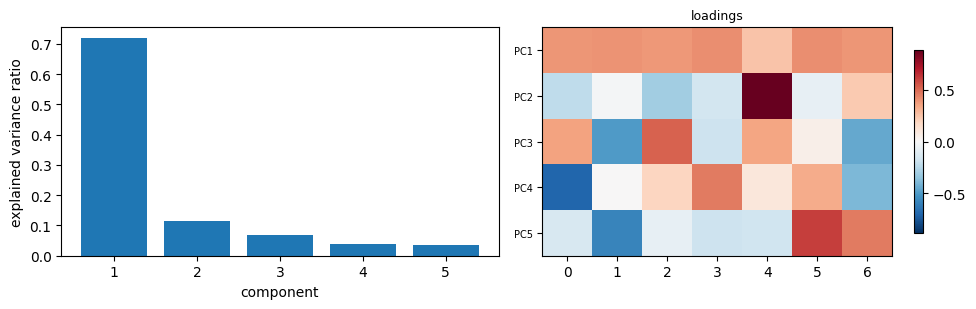

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].bar(range(1, k + 1), ratio[:k])
ax[0].set_xlabel("component"); ax[0].set_ylabel("explained variance ratio")
im = ax[1].imshow(loadings.T, aspect="auto", cmap="RdBu_r",
                  vmin=-np.abs(loadings.values).max(),
                  vmax=np.abs(loadings.values).max())
ax[1].set_yticks(range(k)); ax[1].set_yticklabels(loadings.columns, fontsize=7)
ax[1].set_title("loadings", fontsize=9)
fig.colorbar(im, ax=ax[1], shrink=0.8)
fig.tight_layout()

In [18]:
scores_camcan = pd.read_csv(
    "/project/6008063/tamires/cohorts/camcan/dataman/useraccess/opendata/paule_toussaint_camcan01870/approved_data.tsv",
    delimiter="\t")
scores_camcan.columns[scores_camcan.columns.str.contains('anxiety|depression', case=False, regex=True)]

Index(['additional_HADS_anxiety', 'additional_HADS_depression'], dtype='object')